# Person 2 — Step 1: Title Linguistic Feature Analysis

Extracts features from video titles:
- Length, punctuation patterns (questions, exclamations, numbers)
- Emotional/power word counts (using VADER + a science-specific lexicon)
- Readability scores
- Compare distributions institutional vs. independent
- Correlate with engagement

In [9]:
import sys
sys.path.append('../../')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from scipy import stats

from shared.config import VIDEOS_CSV, CHANNELS_CSV, PERSON2_DIR

FIGURES = PERSON2_DIR / 'outputs' / 'figures'
TABLES  = PERSON2_DIR / 'outputs' / 'tables'

plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = {'independent': '#2ecc71', 'institutional': '#3498db'}

## Load & merge data

In [10]:
videos = pd.read_csv(VIDEOS_CSV, parse_dates=['published_at'])
channels = pd.read_csv(CHANNELS_CSV)

df = videos.merge(channels[['channel_id', 'channel_title', 'group_label']], on='channel_id')
df['group_label'] = df['group_label'].str.lower()

# engagement ratio — avoids raw count bias from channel size
df['like_rate']    = df['like_count']    / df['view_count']
df['comment_rate'] = df['comment_count'] / df['view_count']

print(df.shape)
df[['title', 'channel_title', 'group_label', 'view_count', 'like_rate']].head()

(9569, 18)


,title,channel_title,group_label,view_count,like_rate
0,NExT: Bing Overseas Studies,Stanford,institutional,3119.0,0.002565
1,Mark Hartney: ARPA-E and Funding R&D of Advanc...,Stanford,institutional,4314.0,0.008809
2,ETH Zürich: Bereit?,ETH Zürich,institutional,99700.0,0.010411
3,Lecture 3: MVVM and the Swift type system,Stanford,institutional,178472.0,0.013627
4,Stanford course teaches neuroscience through r...,Stanford,institutional,11831.0,0.027132


## Feature extraction from titles

In [11]:
sia = SentimentIntensityAnalyzer()

# Power/curiosity words common in science YouTube
POWER_WORDS = [
    'why', 'how', 'what', 'secret', 'truth', 'never', 'always', 'impossible',
    'actually', 'really', 'mind', 'blow', 'amazing', 'surprising', 'shocking',
    'explained', 'works', 'wrong', 'myth', 'debunk', 'discover', 'proof'
]

def extract_title_features(title: str) -> dict:
    t = str(title)
    tl = t.lower()
    words = tl.split()
    vader = sia.polarity_scores(t)
    return {
        'title_len_chars':    len(t),
        'title_len_words':    len(words),
        'has_question':       int('?' in t),
        'has_exclamation':    int('!' in t),
        'has_number':         int(bool(re.search(r'\d', t))),
        'has_colon':          int(':' in t),
        'starts_with_how':    int(tl.startswith('how')),
        'starts_with_why':    int(tl.startswith('why')),
        'starts_with_what':   int(tl.startswith('what')),
        'all_caps_words':     sum(1 for w in t.split() if w.isupper() and len(w) > 1),
        'power_word_count':   sum(1 for pw in POWER_WORDS if pw in words),
        'vader_compound':     vader['compound'],
        'vader_positive':     vader['pos'],
        'vader_negative':     vader['neg'],
    }

features = df['title'].apply(extract_title_features).apply(pd.Series)
df = pd.concat([df, features], axis=1)


Features added: ['title_len_chars', 'title_len_words', 'has_question', 'has_exclamation', 'has_number', 'has_colon', 'starts_with_how', 'starts_with_why', 'starts_with_what', 'all_caps_words', 'power_word_count', 'vader_compound', 'vader_positive', 'vader_negative']


## Distribution comparison: institutional vs. independent

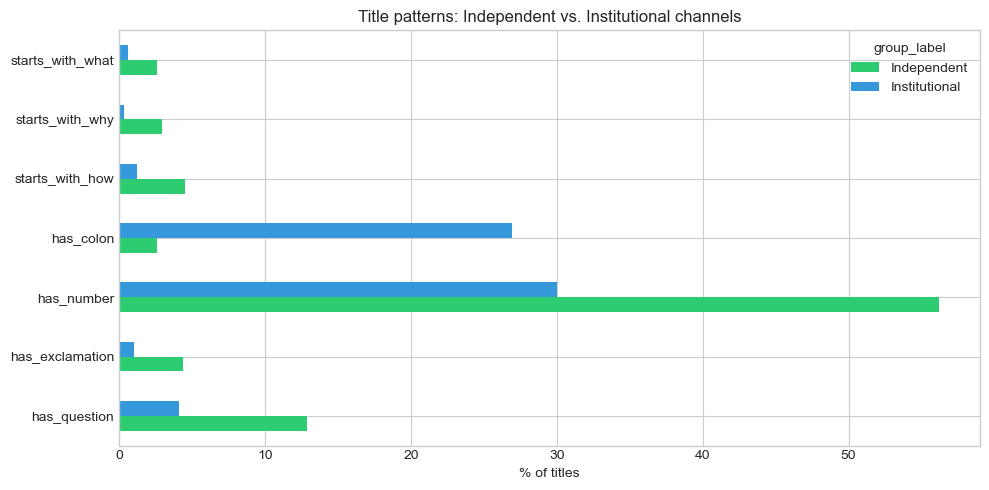

group_label,Independent,Institutional
has_question,12.9,4.1
has_exclamation,4.4,1.0
has_number,56.2,30.0
has_colon,2.6,26.9
starts_with_how,4.5,1.2
starts_with_why,2.9,0.3
starts_with_what,2.6,0.6


In [12]:
binary_features = [
    'has_question', 'has_exclamation', 'has_number', 'has_colon',
    'starts_with_how', 'starts_with_why', 'starts_with_what'
]

pct = (
    df.groupby('group_label')[binary_features]
    .mean()
    .mul(100)
    .round(1)
    .T
    .rename(columns=lambda c: c.title())
)

fig, ax = plt.subplots(figsize=(10, 5))
pct.plot(kind='barh', ax=ax, color=[PALETTE['independent'], PALETTE['institutional']])
ax.set_xlabel('% of titles')
ax.set_title('Title patterns: Independent vs. Institutional channels')
plt.tight_layout()
plt.savefig(FIGURES / 'title_patterns_comparison.png', dpi=150)
plt.show()
pct

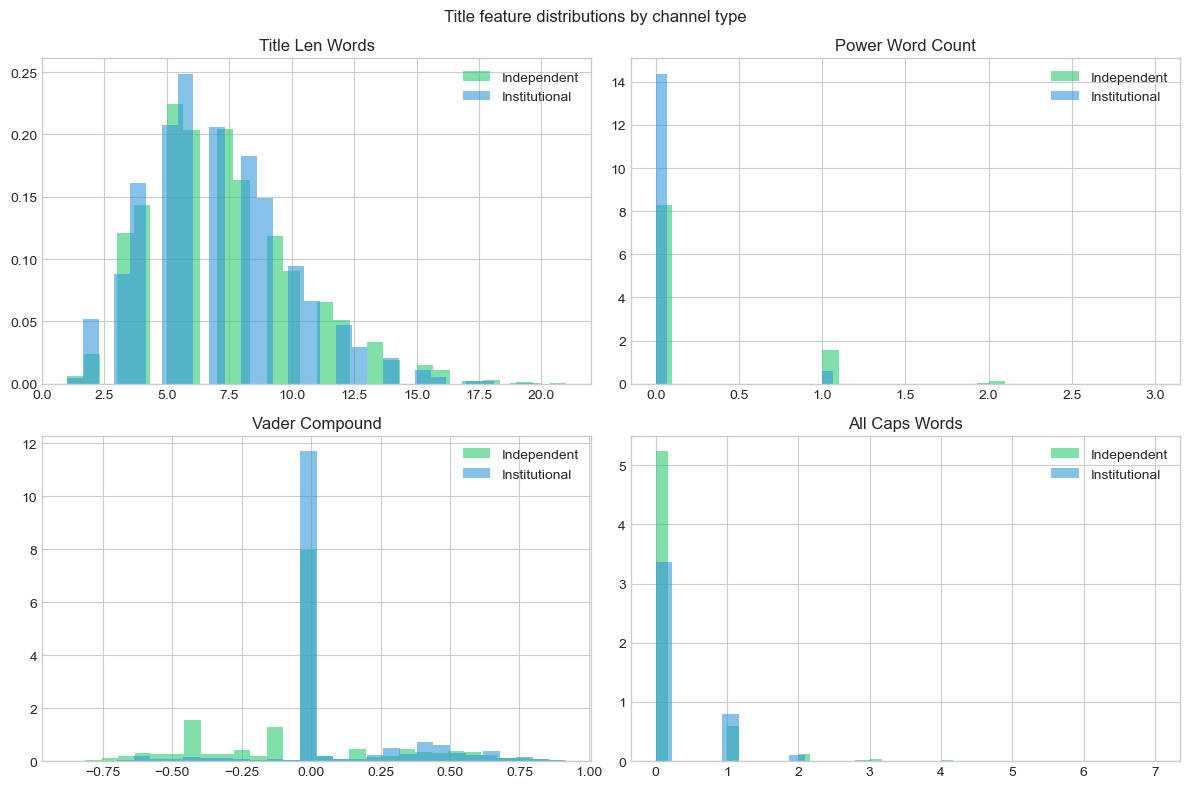

In [13]:
# Continuous features distributions
cont_features = ['title_len_words', 'power_word_count', 'vader_compound', 'all_caps_words']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, feat in zip(axes.flat, cont_features):
    for grp, color in PALETTE.items():
        subset = df[df['group_label'] == grp][feat].dropna()
        subset.hist(ax=ax, bins=30, alpha=0.6, color=color, label=grp.title(), density=True)
    ax.set_title(feat.replace('_', ' ').title())
    ax.legend()
plt.suptitle('Title feature distributions by channel type')
plt.tight_layout()
plt.savefig(FIGURES / 'title_distributions.png', dpi=150)
plt.show()

## Statistical tests (Mann-Whitney U)

In [14]:
test_features = cont_features + ['has_question', 'has_number', 'has_exclamation']

indep = df[df['group_label'] == 'independent']
inst  = df[df['group_label'] == 'institutional']

results = []
for feat in test_features:
    a, b = indep[feat].dropna(), inst[feat].dropna()
    u, p  = stats.mannwhitneyu(a, b, alternative='two-sided')
    results.append({
        'feature':     feat,
        'independent_mean': a.mean(),
        'institutional_mean': b.mean(),
        'p_value':     p,
        'significant': p < 0.05
    })

stats_df = pd.DataFrame(results).sort_values('p_value')
stats_df.to_csv(TABLES / 'title_stats_tests.csv', index=False)
stats_df

,feature,independent_mean,institutional_mean,p_value,significant
5,has_number,0.562402,0.299815,2.638889e-122,True
1,power_word_count,0.182496,0.044153,2.240547e-95,True
2,vader_compound,-0.022484,0.075745,8.034551e-79,True
4,has_question,0.128728,0.041447,4.024010e-53,True
6,has_exclamation,0.044349,0.009543,1.626110e-28,True
3,all_caps_words,0.166797,0.246831,4.324768e-20,True
0,title_len_words,7.057300,6.998576,9.165022e-01,False


## Correlation with engagement

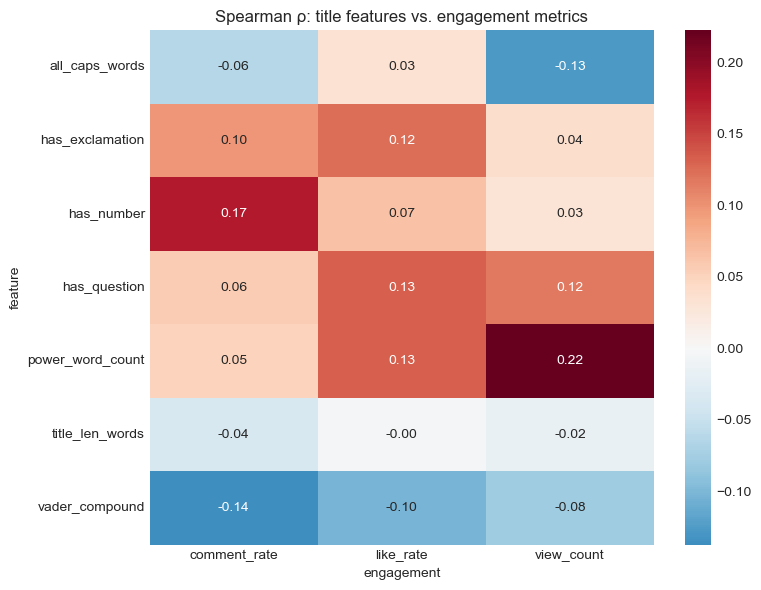

In [15]:
engagement_cols = ['view_count', 'like_rate', 'comment_rate']

corr_rows = []
for feat in test_features:
    for eng in engagement_cols:
        sub = df[[feat, eng]].dropna()
        r, p = stats.spearmanr(sub[feat], sub[eng])
        corr_rows.append({'feature': feat, 'engagement': eng, 'rho': r, 'p_value': p})

corr_df = pd.DataFrame(corr_rows)
pivot = corr_df.pivot(index='feature', columns='engagement', values='rho')

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(pivot, annot=True, fmt='.2f', center=0, cmap='RdBu_r', ax=ax)
ax.set_title('Spearman ρ: title features vs. engagement metrics')
plt.tight_layout()
plt.savefig(FIGURES / 'title_engagement_correlation.png', dpi=150)
plt.show()

## Per-channel breakdown

In [16]:
channel_summary = (
    df.groupby(['channel_title', 'group_label'])[test_features]
    .mean()
    .round(3)
)
channel_summary.to_csv(TABLES / 'title_features_by_channel.csv')
channel_summary

,,title_len_words,power_word_count,vader_compound,all_caps_words,has_question,has_number,has_exclamation
channel_title,group_label,,,,,,,
3Blue1Brown,independent,7.546,0.323,0.035,0.074,0.148,0.336,0.009
EPFL,institutional,7.483,0.033,0.066,0.283,0.057,0.267,0.004
ETH Zürich,institutional,7.330,0.067,0.084,0.410,0.101,0.252,0.032
Kurzgesagt – In a Nutshell,independent,7.283,0.486,-0.075,0.131,0.346,0.066,0.040
Lectures by Walter Lewin. They will make you ♥ Physics.,independent,7.109,0.048,-0.023,0.181,0.052,0.781,0.047
Massachusetts Institute of Technology (MIT),institutional,5.966,0.031,0.074,0.508,0.014,0.117,0.016
Stanford,institutional,7.057,0.043,0.075,0.136,0.028,0.360,0.003
minutephysics,independent,6.145,0.464,-0.003,0.197,0.283,0.109,0.062
